In [34]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Closure Feed Analysis

In [12]:
alerts_path = Path.cwd() / 'Road_Closure_Feeds'

closures_df = pd.concat(
    [pd.read_csv(f) for f in alerts_path.iterdir() if f.suffix.lower() == ".csv"],
    ignore_index=True
)
closures_df['extraction_date'] = pd.to_datetime(closures_df['extraction_date'])

## Number of Closures Over Time

In [4]:
closure_count_by_park = pd.pivot_table(
    closures_df,
    values='core_details.event_type',
    index = 'organization_name',
    columns='extraction_date',
    aggfunc='count'
)
closure_count_by_park = closure_count_by_park.fillna(0).astype(int)
closure_count_by_park

extraction_date,2026-03-13,2026-03-14,2026-03-15,2026-03-16,2026-03-17,2026-03-18,2026-03-19,2026-03-20,2026-03-21,2026-03-22,2026-03-23
organization_name,,,,,,,,,,,
Black Canyon of the Gunnison National Park,8,8,8,0,8,8,8,8,8,8,8
Blue Ridge Parkway,20,20,20,20,70,70,70,72,72,72,72
Buffalo National River,2,2,2,2,2,2,2,2,2,2,2
Crater Lake National Park,10,10,10,10,10,10,10,10,10,10,10
Curecanti National Recreation Area,2,2,2,0,2,2,2,2,2,2,2
Delaware Water Gap,18,18,18,0,18,18,18,18,18,18,18
Fort Dupont Park,0,0,0,0,20,0,0,0,0,0,0
Golden Gate National Recreation Area,2,2,2,0,2,2,0,0,0,0,0
Grand Canyon National Park,6,6,6,6,6,6,6,6,6,6,6


In [13]:
count = closures_df['extraction_date'].nunique()
print(f'{count} days of daily pulls')

11 days of daily pulls


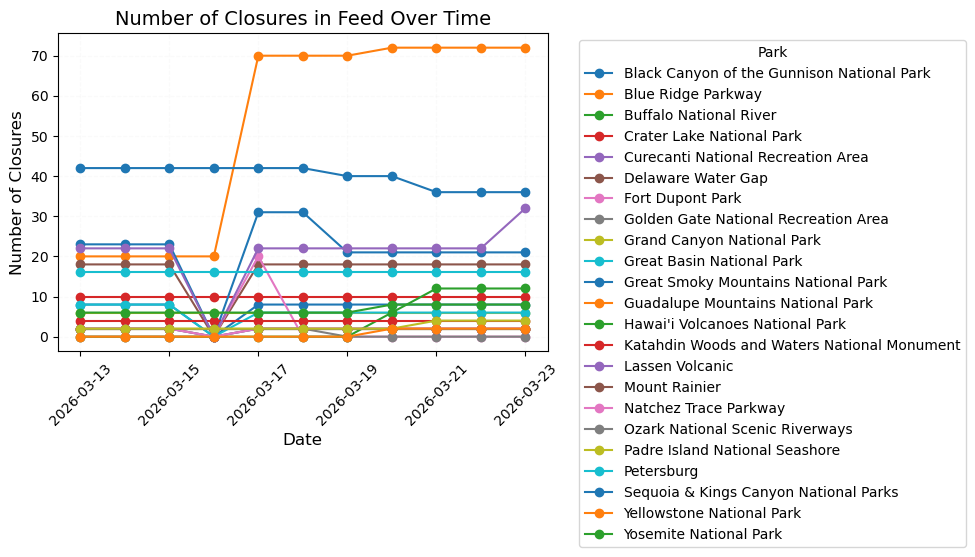

In [ ]:
df_plot = closure_count_by_park.T
plt.figure(figsize=(10, 5))

for column in df_plot.columns:
    plt.plot(df_plot.index, df_plot[column], marker='o', label=column)

plt.title("Number of Closures by Park Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.xticks(rotation=45)
plt.ylabel("Number of Closures", fontsize=12)
plt.legend(title="Park", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=.06)
    
plt.tight_layout()

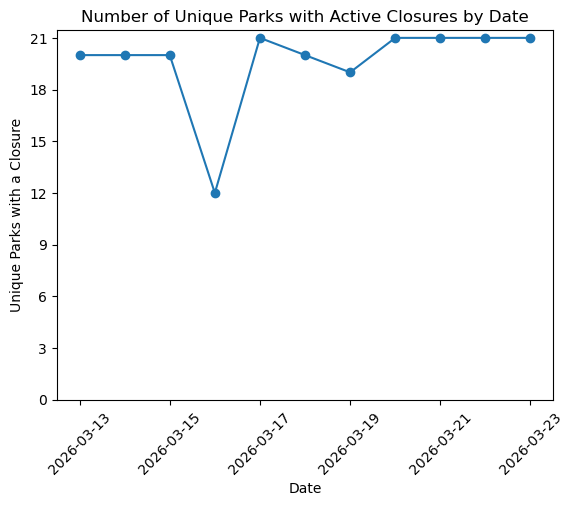

In [35]:
unique_parks_per_day = closures_df.groupby('extraction_date')['organization_name'].nunique()
unique_parks_per_day = pd.DataFrame(unique_parks_per_day)
unique_parks_per_day = unique_parks_per_day.reset_index()

plt.plot(unique_parks_per_day['extraction_date'], unique_parks_per_day['organization_name'], marker='o', linestyle='-')

plt.xlabel('Date')
plt.ylabel('Unique Parks with a Closure')
plt.ylim(bottom=0)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True)) # Force Y-axis to only show whole numbers (integers)
plt.title('Number of Unique Parks with Active Closures by Date')
plt.xticks(rotation=45)

plt.show()

# Alerts Feed Analysis

In [6]:
alerts_path = Path.cwd() / 'Alerts_Feeds'

alerts_df = pd.concat(
    [pd.read_csv(f) for f in alerts_path.iterdir() if f.suffix.lower() == ".csv"],
    ignore_index=True
)

## Number of Alerts Over Time

In [7]:
alerts_count_by_park = pd.pivot_table(
    alerts_df,
    values='id',
    index = 'parkCode',
    columns='extraction_date',
    aggfunc='count'
)
alerts_count_by_park = alerts_count_by_park.fillna(0).astype(int)
alerts_count_by_park

extraction_date,2026-03-13,2026-03-14,2026-03-15,2026-03-16,2026-03-17,2026-03-18,2026-03-19,2026-03-20
parkCode,,,,,,,,
abli,0,0,0,1,1,1,1,0
acad,1,1,1,1,2,2,3,3
adam,3,3,3,3,3,3,3,3
afbg,1,1,1,1,1,1,1,1
agfo,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...
yell,4,4,4,3,4,4,4,4
york,1,1,1,1,1,1,1,1
yose,1,1,1,1,1,1,1,1
